# Xeno-canto Gathering

Build a reproducible download set using XC query tags.


In [ ]:
import json
import sys
import time
from pathlib import Path

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "src" / "config.py").exists():
    repo_root = repo_root.parent
if not (repo_root / "src" / "config.py").exists():
    raise FileNotFoundError(f"Couldn't find src/config.py from {Path.cwd()}")

sys.path.insert(0, str(repo_root))

from src.config import CONFIG
from src.dataset.utils.xeno_canto import write_raw_manifest_for_species, download_from_selected_manifest
from src.dataset.utils.gathering import write_selected_manifests


In [8]:
DATA_DIR = Path(CONFIG.paths.data_dir)
RAW_DIR = DATA_DIR / CONFIG.paths.raw_dir
MANIFEST_DIR = DATA_DIR / CONFIG.paths.manifests_dir

for p in [RAW_DIR, MANIFEST_DIR]:
    p.mkdir(parents=True, exist_ok=True)
    
SPECIES_FILE = Path("../../species_list_small.json")
species_map = json.loads(SPECIES_FILE.read_text(encoding="utf-8"))
species_list = list(species_map.values())
species_list[:5]

[{'common_name': 'European Robin', 'sci_name': 'Erithacus rubecula'},
 {'common_name': 'Eurasian Blackbird', 'sci_name': 'Turdus merula'},
 {'common_name': 'Eurasian Wren', 'sci_name': 'Troglodytes troglodytes'},
 {'common_name': 'Eurasian Blue Tit', 'sci_name': 'Cyanistes caeruleus'},
 {'common_name': 'Great Tit', 'sci_name': 'Parus major'}]

In [9]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent  # or walk parents robustly

DATA_DIR = PROJECT_ROOT / CONFIG.paths.data_dir
RAW_DIR = DATA_DIR / CONFIG.paths.raw_dir
MANIFEST_DIR = DATA_DIR / CONFIG.paths.manifests_dir
print(MANIFEST_DIR, len(list(MANIFEST_DIR.glob("*_selected.csv"))))


/Users/justyna-przy/Projects/ISE/FYP/src/dataset/bird_data/manifests 152


In [10]:
def build_query(sci_name: str) -> str:
    xc = CONFIG.xeno_canto
    tags = [
        f'sp:"{sci_name}"',
        "grp:birds",
        "area:europe",
        'q:">C"',                 
        f'len:">{xc.min_len}"',
        f'len:"<{xc.max_len}"',
    ]
    return " ".join(tags)


## Fetch metadata and store in manifest files


In [11]:
for entry in species_list:
    sci_name = entry["sci_name"]
    query = build_query(sci_name)

    out_csv = write_raw_manifest_for_species(
        sci_name=sci_name,
        query=query,
        manifest_dir=MANIFEST_DIR,
        per_page=500,
    )

    print(f"Wrote raw manifest: {out_csv}")


Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/dataset/bird_data/manifests/erithacus_rubecula.csv
Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/dataset/bird_data/manifests/turdus_merula.csv
Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/dataset/bird_data/manifests/troglodytes_troglodytes.csv
Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/dataset/bird_data/manifests/cyanistes_caeruleus.csv
Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/dataset/bird_data/manifests/parus_major.csv
Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/dataset/bird_data/manifests/carduelis_carduelis.csv
Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/dataset/bird_data/manifests/fringilla_coelebs.csv
Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/dataset/bird_data/manifests/turdus_philomelos.csv
Wrote raw manifest: /Users/justyna-przy/Projects/ISE/FYP/src/dataset/bird_data/manifests/pica_pica.csv
Wrote ra

In [12]:
summary = write_selected_manifests(
    MANIFEST_DIR,
    target_per_species=250,             
    recordist_cap=30,
    prefer_countries=("Ireland", "United Kingdom"),
    selected_suffix="selected",
)

# Print a readable per-species summary
for fname, info in summary["per_file"].items():
    stats = info.get("stats", {})
    if not stats:
        print(fname, info)
        continue
    print(f"\n=== {fname} ===")
    print("selected:", stats["selected"], "/", stats["total_in"])
    print("IE/UK:", stats["preferred_selected"], f"({stats['preferred_selected_pct']:.1f}%)")
    print("month coverage:", stats["selected_month_coverage"])
    print("max by one recordist:", stats["max_selected_by_one_recordist"])
    print("top countries:", stats["selected_country_top"][:5])


=== accipiter_nisus.csv ===
selected: 127 / 127
IE/UK: 28 (22.0%)
month coverage: 10
max by one recordist: 10
top countries: [('United Kingdom', 24), ('France', 21), ('Sweden', 20), ('Poland', 17), ('Germany', 13)]

=== accipiter_nisus_clips.csv ===
selected: 250 / 358
IE/UK: 0 (0.0%)
month coverage: 0
max by one recordist: 0
top countries: [('', 250)]

=== accipiter_nisus_downloaded.csv ===
selected: 127 / 127
IE/UK: 28 (22.0%)
month coverage: 10
max by one recordist: 10
top countries: [('United Kingdom', 24), ('France', 21), ('Sweden', 20), ('Poland', 17), ('Germany', 13)]

=== acrocephalus_schoenobaenus.csv ===
selected: 250 / 552
IE/UK: 124 (49.6%)
month coverage: 10
max by one recordist: 25
top countries: [('United Kingdom', 81), ('Ireland', 43), ('France', 33), ('Sweden', 22), ('Portugal', 14)]

=== acrocephalus_schoenobaenus_clips.csv ===
selected: 250 / 932
IE/UK: 0 (0.0%)
month coverage: 0
max by one recordist: 0
top countries: [('', 250)]

=== acrocephalus_schoenobaenus_down

## Summary Figures for Paper

Build per-species summary tables and plot dataset-level figures.

Wrote: /Users/justyna-przy/Projects/ISE/FYP/src/dataset/bird_data/manifests/species_selection_summary_for_paper.csv


,species_file,species_slug,species_sci,ie_uk_count,selected_count,ie_uk_pct,other_pct
0,troglodytes_troglodytes.csv,troglodytes_troglodytes,troglodytes troglodytes,216,250,86.4,13.6
1,erithacus_rubecula.csv,erithacus_rubecula,erithacus rubecula,205,250,82.0,18.0
2,phylloscopus_collybita.csv,phylloscopus_collybita,phylloscopus collybita,203,250,81.2,18.8
3,turdus_merula.csv,turdus_merula,turdus merula,197,250,78.8,21.2
4,turdus_philomelos.csv,turdus_philomelos,turdus philomelos,192,250,76.8,23.2


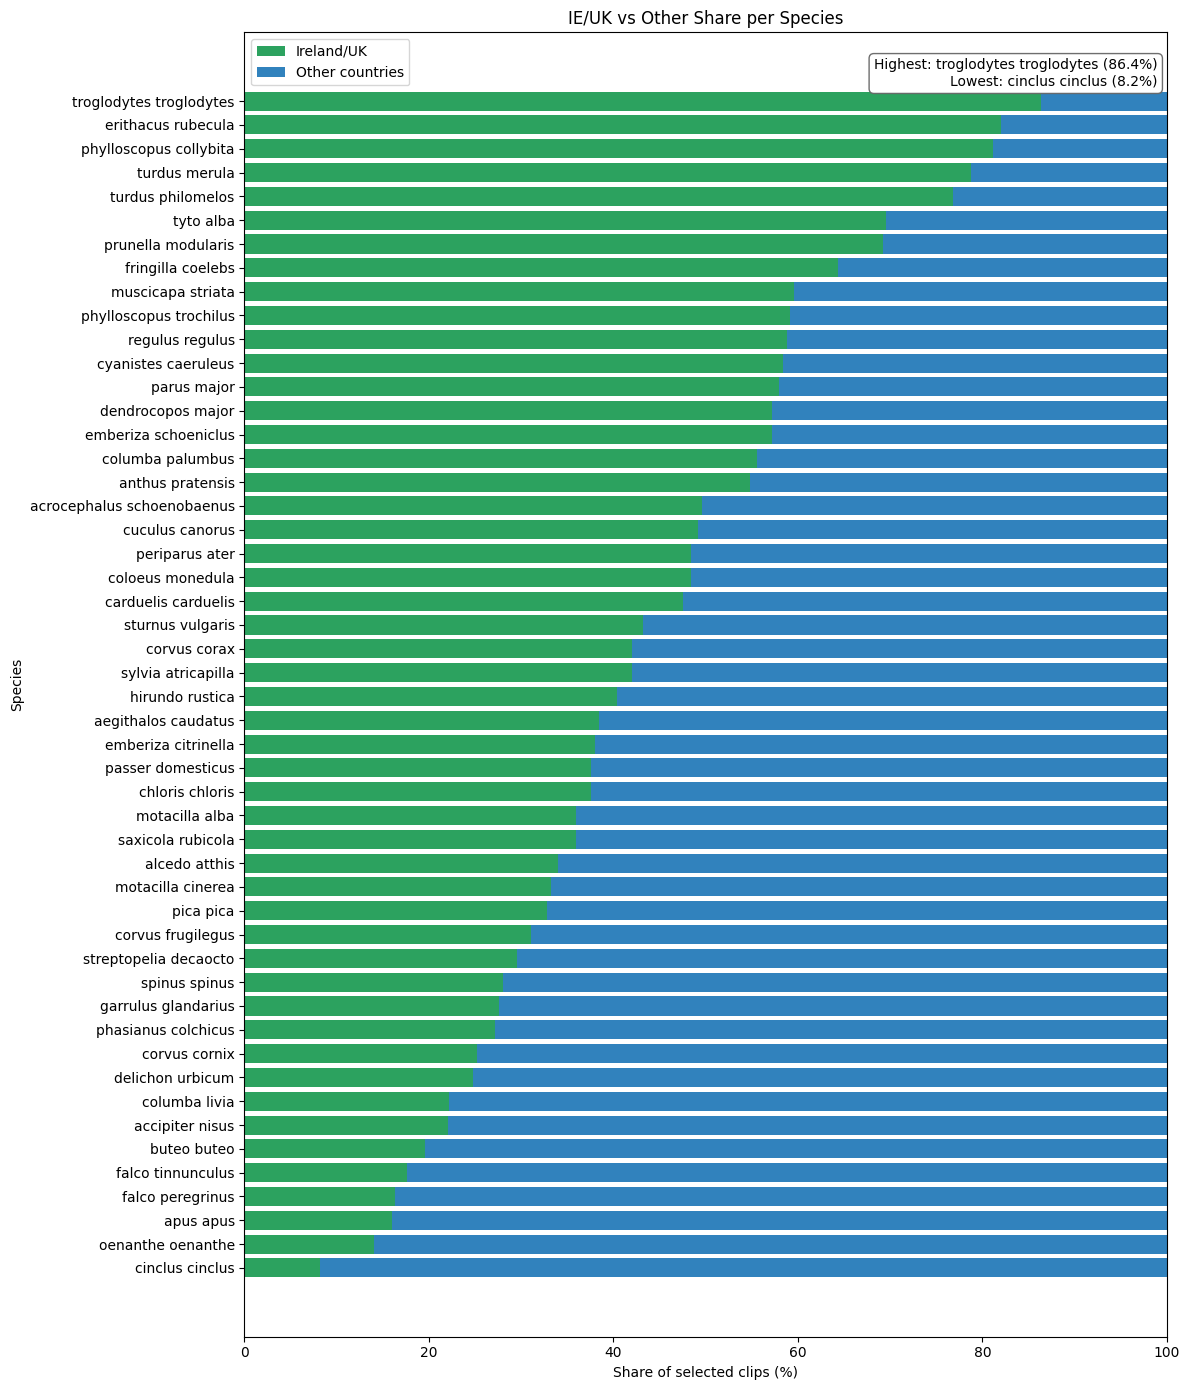

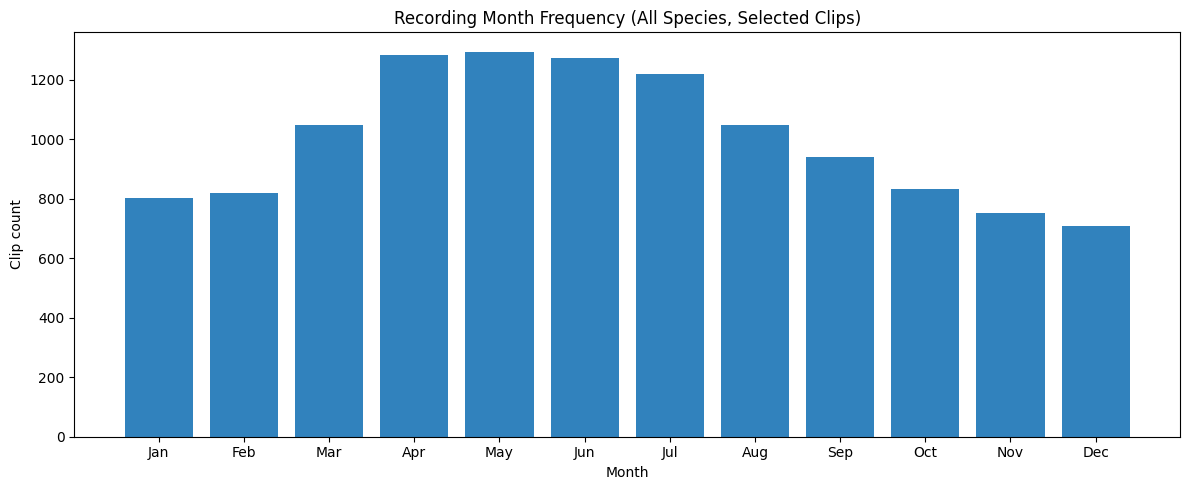

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Build species-level stats table from selection output.
valid_species_slugs = {entry["sci_name"].replace(" ", "_").lower() for entry in species_list}

species_rows = []
for fname, info in summary["per_file"].items():
    stats = info.get("stats") or {}
    if not stats:
        continue

    species_slug = Path(fname).stem.lower()
    if species_slug not in valid_species_slugs:
        continue

    ie_uk_pct = float(stats.get("preferred_selected_pct", 0.0))
    species_rows.append(
        {
            "species_file": fname,
            "species_slug": species_slug,
            "species_sci": species_slug.replace("_", " "),
            "ie_uk_count": int(stats.get("preferred_selected", 0)),
            "selected_count": int(stats.get("selected", 0)),
            "ie_uk_pct": ie_uk_pct,
            "other_pct": max(0.0, 100.0 - ie_uk_pct),
        }
    )

species_stats_df = pd.DataFrame(species_rows).sort_values("ie_uk_pct", ascending=False).reset_index(drop=True)
if species_stats_df.empty:
    raise RuntimeError("No species-level stats found. Re-run selection cell before plotting.")

paper_summary_csv = MANIFEST_DIR / "species_selection_summary_for_paper.csv"
species_stats_df.to_csv(paper_summary_csv, index=False)
print("Wrote:", paper_summary_csv)
display(species_stats_df.head())

# 1) IE/UK share per species: green (IE/UK) + blue (other countries).
fig, ax = plt.subplots(figsize=(12, max(10, 0.28 * len(species_stats_df))))
ax.barh(species_stats_df["species_sci"], species_stats_df["ie_uk_pct"], color="#2ca25f", label="Ireland/UK")
ax.barh(
    species_stats_df["species_sci"],
    species_stats_df["other_pct"],
    left=species_stats_df["ie_uk_pct"],
    color="#3182bd",
    label="Other countries",
)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Share of selected clips (%)")
ax.set_ylabel("Species")
ax.set_title("IE/UK vs Other Share per Species")
ax.legend(loc="upper left")

highest = species_stats_df.iloc[0]
lowest = species_stats_df.iloc[-1]
callout = (
    f"Highest: {highest['species_sci']} ({highest['ie_uk_pct']:.1f}%)\n"
    f"Lowest: {lowest['species_sci']} ({lowest['ie_uk_pct']:.1f}%)"
)
ax.text(
    0.99,
    0.98,
    callout,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#666666", "alpha": 0.95},
)
plt.tight_layout()
plt.show()

# 2) Month frequency aggregated across all species.
month_frames = []
for species_slug in sorted(valid_species_slugs):
    p = MANIFEST_DIR / f"{species_slug}_selected.csv"
    if not p.exists():
        continue
    frame = pd.read_csv(p)
    if "date" not in frame.columns:
        continue
    month_frames.append(frame[["date"]])

if month_frames:
    months_all = pd.concat(month_frames, ignore_index=True)
    months_all["date"] = pd.to_datetime(months_all["date"], errors="coerce")
    month_counts = months_all["date"].dt.month.value_counts().reindex(range(1, 13), fill_value=0)
else:
    month_counts = pd.Series([0] * 12, index=range(1, 13))

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(month_labels, month_counts.values, color="#3182bd")
ax.set_title("Recording Month Frequency (All Species, Selected Clips)")
ax.set_xlabel("Month")
ax.set_ylabel("Clip count")
plt.tight_layout()
plt.show()


In [14]:
from pathlib import Path

SKIP_SCI = {
}



def sci_name_from_selected_file(p: Path) -> str:
    name = p.name
    if not name.endswith("_selected.csv"):
        raise ValueError(f"Not a selected manifest: {name}")
    slug = name[:-len("_selected.csv")]
    return slug.replace("_", " ")

def downloaded_manifest_path(selected_path: Path) -> Path:
    return selected_path.with_name(selected_path.name.replace("_selected.csv", "_downloaded.csv"))

selected_files = sorted(Path(MANIFEST_DIR).glob("*_selected.csv"))
print("Found selected manifests:", len(selected_files))

downloaded = []
for f in selected_files:
    sci = sci_name_from_selected_file(f)
    downloaded_csv = downloaded_manifest_path(f)

    if downloaded_csv.exists():
        print(f"Already downloaded: {sci}")
        downloaded.append(downloaded_csv)
        continue

    print()
    print(f"=== Downloading {sci} ===")
    try:
        out = download_from_selected_manifest(
            sci_name=sci,
            manifest_dir=MANIFEST_DIR,
            raw_audio_dir=RAW_DIR,
            overwrite=False,
        )
    except Exception as exc:
        print(f"Failed {sci}: {exc}")
        continue
    downloaded.append(out)

print()
print("Done. Downloaded manifests written:")
for p in downloaded:
    print(" -", p)


Found selected manifests: 152

=== Downloading accipiter nisus clips ===
1 / 250
Failed accipiter nisus clips: Invalid URL '': No scheme supplied. Perhaps you meant https://?

=== Downloading accipiter nisus downloaded ===
1 / 127
2 / 127
3 / 127
4 / 127
5 / 127
6 / 127
7 / 127
8 / 127
9 / 127
10 / 127
11 / 127
12 / 127
13 / 127
14 / 127
15 / 127
16 / 127
17 / 127
18 / 127
19 / 127
20 / 127
21 / 127
22 / 127
23 / 127
24 / 127
25 / 127
26 / 127
27 / 127
28 / 127
29 / 127
30 / 127
31 / 127
32 / 127
33 / 127
34 / 127
35 / 127
36 / 127
37 / 127
38 / 127
39 / 127
40 / 127
41 / 127
42 / 127
43 / 127
44 / 127
45 / 127
46 / 127
47 / 127
48 / 127
49 / 127
50 / 127
51 / 127
52 / 127
53 / 127
54 / 127
55 / 127
56 / 127
57 / 127
58 / 127
59 / 127
60 / 127
61 / 127
62 / 127
63 / 127
64 / 127
65 / 127
66 / 127
67 / 127
68 / 127
69 / 127
70 / 127
71 / 127
72 / 127
73 / 127
74 / 127
75 / 127
76 / 127
77 / 127
78 / 127
79 / 127
80 / 127
81 / 127
82 / 127
83 / 127
84 / 127
85 / 127
86 / 127
87 / 127
88 

KeyboardInterrupt: 